In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score
import random
from tqdm import tqdm

In [2]:
# Load California Housing dataset
data = fetch_california_housing(as_frame=True)
df = data.frame

In [3]:
print("Dataset Info:")
print(df.info())

print("\nDataset Description:")
print(df.describe())

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB
None

Dataset Description:
             MedInc      HouseAge      AveRooms     AveBedrms    Population  \
count  20640.000000  20640.000000  20640.000000  20640.000000  20640.000000   
mean       3.870671     28.639486      5.429000      1.096675   1425.476744   
std        1.899822     12.585558      2.474173      0.473911   1132.462122   
min        0.499900      1.000000

In [4]:
print("\nMissing Values:")
print(df.isnull().sum())


Missing Values:
MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64


In [5]:
# Calculate and print the correlation matrix 
correlation_matrix = df.corr()
print("Correlation Matrix:")
print(correlation_matrix)

Correlation Matrix:
               MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  \
MedInc       1.000000 -0.119034  0.326895  -0.062040    0.004834  0.018766   
HouseAge    -0.119034  1.000000 -0.153277  -0.077747   -0.296244  0.013191   
AveRooms     0.326895 -0.153277  1.000000   0.847621   -0.072213 -0.004852   
AveBedrms   -0.062040 -0.077747  0.847621   1.000000   -0.066197 -0.006181   
Population   0.004834 -0.296244 -0.072213  -0.066197    1.000000  0.069863   
AveOccup     0.018766  0.013191 -0.004852  -0.006181    0.069863  1.000000   
Latitude    -0.079809  0.011173  0.106389   0.069721   -0.108785  0.002366   
Longitude   -0.015176 -0.108197 -0.027540   0.013344    0.099773  0.002476   
MedHouseVal  0.688075  0.105623  0.151948  -0.046701   -0.024650 -0.023737   

             Latitude  Longitude  MedHouseVal  
MedInc      -0.079809  -0.015176     0.688075  
HouseAge     0.011173  -0.108197     0.105623  
AveRooms     0.106389  -0.027540     0.151948  
AveBedr

In [6]:
# Droping features with high correlation with each other [Removing Multicollinearity]
threshold = 0.8
columns_to_drop = set()  
target = 'MedHouseVal'
correlation_matrix = df.drop(columns=[target]).corr()
for i in range(len(correlation_matrix.columns)):
    for j in range(i):
        if abs(correlation_matrix.iloc[i, j]) > threshold:
            colname = correlation_matrix.columns[i]
            columns_to_drop.add(colname)

df = df.drop(columns=columns_to_drop)

print(f"\nFeatures dropped due to high correlation (> {threshold}): {columns_to_drop}")
print("\nRemaining features:")
print(df.columns.tolist())


Features dropped due to high correlation (> 0.8): {'Longitude', 'AveBedrms'}

Remaining features:
['MedInc', 'HouseAge', 'AveRooms', 'Population', 'AveOccup', 'Latitude', 'MedHouseVal']


In [7]:
# Function to remove outliers using IQR
def remove_outliers_iqr(df, feature_column):
    Q1 = df[feature_column].quantile(0.25)
    Q3 = df[feature_column].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    return df[(df[feature_column] >= lower_bound) & (df[feature_column] <= upper_bound)]

# Remove outliers from the target variable
df = remove_outliers_iqr(df, target)

In [8]:
# Features and target
X = df.drop(columns=["MedHouseVal"])
y = df["MedHouseVal"]

In [9]:
# Batch Gradient Descent for Regression
def batch_gradient_descent(X_train, y_train, X_val, y_val, learning_rate=0.01, epochs=1000):
    n_samples, n_features = X_train.shape
    weights = np.zeros((n_features, 1))
    bias = 0
    training_loss = []
    validation_loss = []

    y_train = y_train.values.reshape(-1, 1)  # Convert to 2D array
    y_val = y_val.values.reshape(-1, 1)

    for epoch in tqdm(range(epochs)):
        # Predictions
        y_pred = np.dot(X_train, weights) + bias

        # Gradients
        dw = -(2 / n_samples) * np.dot(X_train.T, (y_train - y_pred))
        db = -(2 / n_samples) * np.sum(y_train - y_pred)

        # Update weights and bias
        weights -= learning_rate * dw
        bias -= learning_rate * db

        # Calculate training loss
        train_loss = np.mean((y_train - y_pred) ** 2)
        training_loss.append(train_loss)

        # Calculate validation loss
        val_loss = np.mean((y_val - (np.dot(X_val, weights) + bias)) ** 2)
        validation_loss.append(val_loss)

    return weights, bias, training_loss, validation_loss

In [10]:
def k_fold_cross_validation(X, y, k=5, learning_rate=0.001, epochs=1000):
    kf = KFold(n_splits=k)
    r2_scores = []
    all_training_losses = []
    all_validation_losses = []

    for train_index, val_index in kf.split(X):
        X_train, X_val = X.iloc[train_index], X.iloc[val_index]  # Change here
        y_train, y_val = y.iloc[train_index], y.iloc[val_index]

        # Standardize features for the current fold
        scaler = StandardScaler()
        X_train = scaler.fit_transform(X_train)
        X_val = scaler.transform(X_val)

        weights, bias, training_loss, validation_loss = batch_gradient_descent(
            X_train, y_train, X_val, y_val, learning_rate, epochs
        )

        # Make predictions on validation set
        y_pred = np.dot(X_val, weights) + bias

        # Calculate R² score
        r2 = r2_score(y_val, y_pred)
        r2_scores.append(r2)

        all_training_losses.append(training_loss)
        all_validation_losses.append(validation_loss)

    # Calculate mean training and validation losses across folds
    mean_training_loss = np.mean(all_training_losses, axis=0)
    mean_validation_loss = np.mean(all_validation_losses, axis=0)
    
    return np.mean(r2_scores), mean_training_loss, mean_validation_loss

In [11]:
average_r2, mean_training_loss, mean_validation_loss = k_fold_cross_validation(
    X, y, k=5, learning_rate=0.001, epochs=1000
)
print(f"Average R² Score across all folds: {average_r2:.4f}")

100%|████████████████████████████████████████████████████████████████████████████| 1000/1000 [00:00<00:00, 1787.51it/s]

Average R² Score across all folds: 0.3051


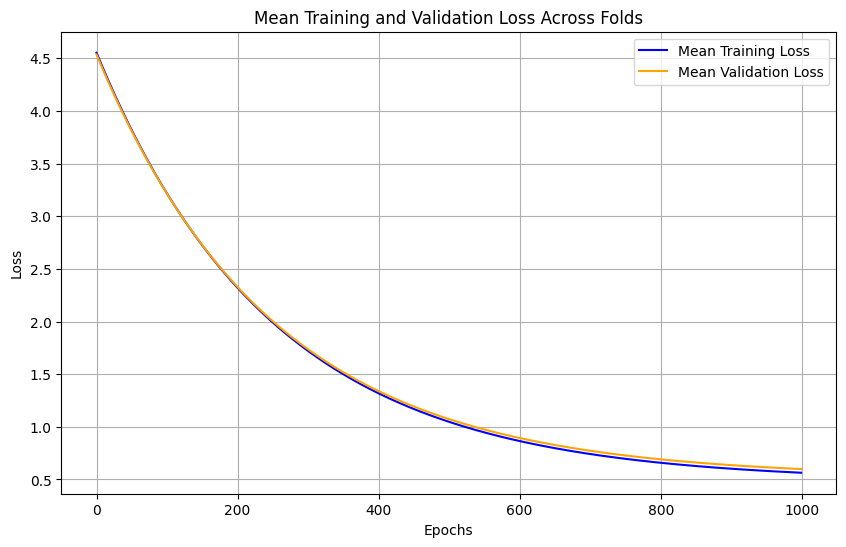

In [12]:
# Plot the mean losses
epochs = len(mean_training_loss)
plt.figure(figsize=(10, 6))
plt.plot(range(epochs), mean_training_loss, label="Mean Training Loss", color="blue")
plt.plot(range(epochs), mean_validation_loss, label="Mean Validation Loss", color="orange")

plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Mean Training and Validation Loss Across Folds")
plt.legend()
plt.grid()
plt.show()